In [1]:
from utils import (
    load_session_dumps,
    build_session_summary,
    preprocess_dumps,
    flag_outlier_dumps,
    vlsr_correction,
    build_overlap_grid,
    build_lsr_pairs,
    flag_outlier_pairs,
    combine_viable_pairs,
    compute_cell_metrics,
    neighbor_qa,
    collect_reobserve,
)
from plotters import (
    plot_spectra_grid,
    plot_survey_mollweide,
    plot_survey_mollweide_gridded,
    spectra_per_session_pdf,
)
from ugradiolab import plotting
from ugradiolab.plotting import SS_MICRO, SS_FINE

from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

# --- Hardware / signal-processing constants ---
SAMPLE_RATE_HZ = 3.2e6
NFFT = 1024
F1_MHZ = 1419.86
F2_MHZ = 1421.14
HPBW_DEG = 3.4
# NBLOCKS * NSAMPLES / fs (post-rewrite main pipeline)
INT_TIME_S = 1025 * 16384 / SAMPLE_RATE_HZ  # ~5.25 s

# --- RFI channel flagger ---
RFI_WINDOW = 15
RFI_SIGMA = 10.0
RFI_CHEB_DEGREE = 3
RFI_SAMPLE_FRAC = 0.7
RFI_EXTREMA_ORDER = 2

# --- Outlier dump filter ---
SHAPE_DEV_THRESH = 0.05
SHAPE_FRAC_THRESH = 0.05
SHAPE_MIN_GROUP_SIZE = 3

# --- Frequency switching ---
EDGE_TRIM_MHZ = 0.256

# --- Cross-session pair filter (on dimensionless R) ---
PAIR_NSIGMA = 5.0
PAIR_FRAC_THRESH = 0.15
MIN_VIABLE_PAIRS = 3
PAIR_SPECTRUM_KEY = 'R_lsr'

# --- Per-cell metrics ---
METRIC_MIN_VALID_CH = 8
METRIC_NOISE_V_MAX_KMS = -100.0
METRIC_SIGNAL_V_LO_KMS = -80.0
METRIC_SIGNAL_V_HI_KMS = 60.0
METRIC_SMOOTH_KERNEL = 5
METRIC_PEAK_MIN_SEP_KMS = 4.0
METRIC_PEAK_PROM_NSIGMA = 2.5
METRIC_MIN_NOISE_CH = 5

# --- Neighbor QA (operates on R; W is in km/s) ---
NEIGHBOR_MAX_SEP_DEG = 2.1
MIN_NEIGHBORS = 2
W_Z_THRESH = 3.0
W_FRAC_THRESH = 0.30
W_SCALE_FLOOR = 5.0
PEAK_V_Z_THRESH = 3.0
PEAK_V_ABS_THRESH = 15.0
PEAK_V_MIN_SIGMA = 3.0
PEAK_V_SCALE_FLOOR = 20.0
BIMODAL_MIN_RATIO = 0.68

# --- Paths / display ---
DATA_DIRS = [Path('data/main'), Path('data/nps')]
REOBSERVE_PATH = Path('artifacts/main_reobserve.json')
SPECTRA_PDF_PATH = Path('artifacts/spectra_per_session.pdf')
STATE_PATH = Path('artifacts/scan_load_state.pkl')
MOLL_CENTER_L = 120.0

get_ipython().run_line_magic('matplotlib', 'inline')


/home/ikaros/projects/ay-121/.venv/lib/python3.12/site-packages/rtlsdr/__init__.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 1. Load raw dumps

In [2]:
records = load_session_dumps(DATA_DIRS, skip_recal=True)
sessions = sorted({r['session'] for r in records})

display(build_session_summary(records, INT_TIME_S))

n_sci = sum(1 for r in records if not r['noise_on'])
n_cal = sum(1 for r in records if r['noise_on'])
lo_unique = sorted({r['lo_mhz'] for r in records if not r['noise_on']})
print(f'Total: {len(records)} dumps ({n_sci} obs, {n_cal} cal), '
      f'{len(sessions)} sessions, LO: {lo_unique}')


,Session,UTC Start,UTC End,Wall (min),Obs. Cells,Dumps,Duty %
0,main/session_002,2026-05-14 01:56,2026-05-14 02:40,44.0,24,288,57.3
1,nps/session_001,2026-05-14 02:59,2026-05-14 06:11,191.9,100,1201,54.7


Total: 1489 dumps (992 obs, 497 cal), 2 sessions, LO: [1419.86, 1421.14]


## 2. fftshift + RFI flagging + outlier dump filter

In [3]:
n_flagged = preprocess_dumps(
    records,
    pol_key='corr11',
    rfi_window=RFI_WINDOW,
    rfi_sigma=RFI_SIGMA,
    rfi_degree=RFI_CHEB_DEGREE,
    rfi_sample_frac=RFI_SAMPLE_FRAC,
    rfi_extrema_order=RFI_EXTREMA_ORDER,
)
print(f'RFI flagged: {n_flagged} channel samples across {len(records)} dumps')
print('NOTE: using pol 1 (corr11) only -- pol 0 has bad noise-diode coupling at 3.2 MHz')


RFI flagged: 5010 channel samples across 1489 dumps
NOTE: using pol 1 (corr11) only -- pol 0 has bad noise-diode coupling at 3.2 MHz


In [4]:
outlier_records = flag_outlier_dumps(
    records,
    dev_thresh=SHAPE_DEV_THRESH,
    frac_thresh=SHAPE_FRAC_THRESH,
    min_group_size=SHAPE_MIN_GROUP_SIZE,
)
print(f'Outlier dump filter (spectral shape): removed {len(outlier_records)} dumps')
print(f'  (flag if >{SHAPE_FRAC_THRESH:.0%} of channels deviate '
      f'>{SHAPE_DEV_THRESH:.0%} from group median)')
print(f'Remaining: {len(records)} dumps')


Outlier dump filter (spectral shape): removed 0 dumps
  (flag if >5% of channels deviate >5% from group median)
Remaining: 1489 dumps


## 3. Frequency switching (R)

Pair dumps at f1 and f2, compute R = (I_f1 - I_f2) / I_f2.


In [5]:
grid = build_overlap_grid(
    F1_MHZ, F2_MHZ, SAMPLE_RATE_HZ, NFFT,
    edge_trim_mhz=EDGE_TRIM_MHZ,
)
overlap_mask = grid['overlap_mask']
v_overlap = grid['v_overlap']
dv_kms = grid['dv_kms']

print(f'LO pair: ({F1_MHZ}, {F2_MHZ}) MHz')
print(f"Overlap: [{grid['f_overlap_lo']:.2f}, {grid['f_overlap_hi']:.2f}] MHz")
print(f'Velocity (topo): [{v_overlap[-1]:.0f}, {v_overlap[0]:.0f}] km/s')
print(f'dv = {dv_kms:.3f} km/s per channel')


LO pair: (1419.86, 1421.14) MHz
Overlap: [1419.80, 1421.20] MHz
Velocity (topo): [-168, 128] km/s
dv = 0.660 km/s per channel


## 4. LSR correction, cross-session pair filter, and combine

No temperature calibration is applied. All downstream spectra are the
dimensionless frequency-switched ratio R(v_LSR). Pair filtering, neighbor
QA, and the integrated maps all operate in R-space.

Build per-pair R for each cell across all sessions, LSR-shift each pair onto a
common grid, reject outlier pairs via population MAD (cross-session), then
average the surviving pairs. Cells with fewer than `MIN_VIABLE_PAIRS` after
filtering are queued for reobservation.


In [6]:
print('Building LSR-corrected per-pair R...')
cell_pairs, obs_dumps_by_cell, v_lsr_overlap, mean_vcorr = build_lsr_pairs(
    records,
    lo1=F1_MHZ, lo2=F2_MHZ,
    overlap_mask=overlap_mask,
    v_overlap=v_overlap,
    vlsr_correction_fn=vlsr_correction,
)
print(f'Mean v_corr = {mean_vcorr:.2f} km/s -- '
      f'LSR velocity range: [{v_lsr_overlap[-1]:.0f}, {v_lsr_overlap[0]:.0f}] km/s')

n_pairs_total = sum(len(v) for v in cell_pairs.values())
viable_pairs_per_cell, flagged_pair_records = flag_outlier_pairs(
    cell_pairs,
    n_sigma=PAIR_NSIGMA,
    frac_thresh=PAIR_FRAC_THRESH,
    min_pairs=MIN_VIABLE_PAIRS,
    spectrum_key=PAIR_SPECTRUM_KEY,
)
print(f'Pair filter (on {PAIR_SPECTRUM_KEY}): flagged '
      f'{len(flagged_pair_records)}/{n_pairs_total} pairs '
      f'(NSIGMA={PAIR_NSIGMA}, frac>{PAIR_FRAC_THRESH:.0%})')

cell_combined, cells_insufficient_pairs = combine_viable_pairs(
    viable_pairs_per_cell,
    min_pairs=MIN_VIABLE_PAIRS,
    spectrum_key=PAIR_SPECTRUM_KEY,
)
n_valid = sum(1 for v in cell_combined.values()
              if np.count_nonzero(np.isfinite(v['R'])) >= 8)
print(f'Combined (LSR, R-only): {len(cell_combined)} cells '
      f'({n_valid} with >=8 valid channels)')
print(f'Cells with <{MIN_VIABLE_PAIRS} viable pairs: {len(cells_insufficient_pairs)}')


Building LSR-corrected per-pair R...
Mean v_corr = -32.35 km/s -- LSR velocity range: [-200, 96] km/s
Pair filter (on R_lsr): flagged 0/496 pairs (NSIGMA=5.0, frac>15%)
Combined (LSR, R-only): 124 cells (124 with >=8 valid channels)
Cells with <3 viable pairs: 0


/home/ikaros/projects/ay-121/labs/04/utils/qa.py:552: RuntimeWarning: All-NaN slice encountered
  median = np.nanmedian(R_stack, axis=0)
/home/ikaros/projects/ay-121/labs/04/utils/qa.py:553: RuntimeWarning: All-NaN slice encountered
  mad = np.nanmedian(np.abs(R_stack - median), axis=0) * 1.4826
/home/ikaros/projects/ay-121/labs/04/utils/qa.py:612: RuntimeWarning: Mean of empty slice
  'R': np.nanmean(specs, axis=0),


## 5. Neighbour-based QA

QA operates on the dimensionless ratio R(v_LSR). W is in km/s and the
neighbor scale floor `W_SCALE_FLOOR` is set accordingly (~5 km/s).


In [7]:
cell_combined_qa = {
    k: {'R_overlap': v['R'], 'n_pairs': v['n_pairs']}
    for k, v in cell_combined.items()
}
cell_metrics = compute_cell_metrics(
    cell_combined_qa, v_lsr_overlap, dv_kms,
    min_valid_ch=METRIC_MIN_VALID_CH,
    noise_v_max_kms=METRIC_NOISE_V_MAX_KMS,
    signal_v_lo_kms=METRIC_SIGNAL_V_LO_KMS,
    signal_v_hi_kms=METRIC_SIGNAL_V_HI_KMS,
    smooth_kernel=METRIC_SMOOTH_KERNEL,
    peak_min_sep_kms=METRIC_PEAK_MIN_SEP_KMS,
    peak_prom_nsigma=METRIC_PEAK_PROM_NSIGMA,
    min_noise_ch=METRIC_MIN_NOISE_CH,
)
neighbor_cells = neighbor_qa(
    cell_metrics,
    dv_kms=dv_kms,
    hpbw_deg=HPBW_DEG,
    neighbor_max_sep_deg=NEIGHBOR_MAX_SEP_DEG,
    min_neighbors=MIN_NEIGHBORS,
    w_z_thresh=W_Z_THRESH,
    w_frac_thresh=W_FRAC_THRESH,
    w_scale_floor=W_SCALE_FLOOR,
    peak_v_z_thresh=PEAK_V_Z_THRESH,
    peak_v_abs_thresh=PEAK_V_ABS_THRESH,
    peak_v_min_sigma=PEAK_V_MIN_SIGMA,
    peak_v_scale_floor=PEAK_V_SCALE_FLOOR,
    bimodal_min_ratio=BIMODAL_MIN_RATIO,
)

neighbor_flagged = [c for c in neighbor_cells if c['W_flag'] or c['peak_v_flag']]
print(f'Neighbor QA: {len(neighbor_cells)} cells analyzed (on R)')
print(f'  Flags: W={sum(1 for c in neighbor_cells if c["W_flag"])}, '
      f'peak_v={sum(1 for c in neighbor_cells if c["peak_v_flag"])}, '
      f'any={len(neighbor_flagged)}')

if neighbor_flagged:
    print('  Most deviant cells:')

    def _severity(c):
        w = abs(c['W_frac_resid']) if np.isfinite(c['W_frac_resid']) else 0.0
        v = abs(c['peak_v_z']) if np.isfinite(c['peak_v_z']) else 0.0
        return max(w, v)

    for cell in sorted(neighbor_flagged, key=_severity, reverse=True)[:12]:
        print(
            f"    l={cell['gl']:6.2f} b={cell['gb']:3d} "
            f"W_R={cell['W']:+.2f} km/s (frac={cell['W_frac_resid']:+.2f}, z={cell['W_z']:+.2f}) "
            f"v_peak={cell['peak_v']:+.1f} km/s "
            f"(dv={cell['peak_v_resid']:+.1f}, z={cell['peak_v_z']:+.2f}) "
            f"n={cell['neighbor_count']}"
        )


Neighbor QA: 124 cells analyzed (on R)
  Flags: W=2, peak_v=4, any=5
  Most deviant cells:
    l=226.78 b= 68 W_R=+0.20 km/s (frac=-0.42, z=-19.73) v_peak=+59.8 km/s (dv=+65.1, z=+21.71) n=4
    l=231.10 b= 70 W_R=+2.01 km/s (frac=-0.16, z=-12.22) v_peak=-52.4 km/s (dv=-47.8, z=-15.94) n=3
    l=228.18 b= 66 W_R=+2.56 km/s (frac=+0.10, z=+7.19) v_peak=-4.9 km/s (dv=-30.9, z=-10.29) n=4
    l=238.65 b=  6 W_R=+6.45 km/s (frac=-0.07, z=-7.42) v_peak=+18.2 km/s (dv=+19.5, z=+6.49) n=3
    l=242.30 b=  4 W_R=+5.84 km/s (frac=-0.35, z=-37.97) v_peak=+19.5 km/s (dv=+5.4, z=+1.80) n=4


In [8]:
reobs = collect_reobserve(neighbor_cells, cells_insufficient_pairs)
REOBSERVE_PATH.write_text(json.dumps(reobs, indent=2) + '\n')
print(f'Wrote {REOBSERVE_PATH} -- {len(reobs)} cells')
for r in reobs:
    print(f"  l={r['l']:7.2f} b={r['b']:+3d}  ({r['reason']})")


Wrote artifacts/main_reobserve.json -- 5 cells
  l= 242.30 b= +4  (W)
  l= 238.65 b= +6  (peak_v)
  l= 228.18 b=+66  (peak_v)
  l= 226.78 b=+68  (W+peak_v)
  l= 231.10 b=+70  (peak_v)


In [9]:
qa_flagged_set = {(c['gl'], c['gb']) for c in neighbor_cells
                  if c['W_flag'] or c['peak_v_flag']}
insufficient_set = {(c['l'], c['b']) for c in cells_insufficient_pairs}
excluded_cells = qa_flagged_set | insufficient_set

n_pages = spectra_per_session_pdf(
    SPECTRA_PDF_PATH,
    v_lsr_overlap,
    viable_pairs_per_cell,
    excluded_cells,
    sessions,
    spectrum_key=PAIR_SPECTRUM_KEY,
)
print(f'Saved {SPECTRA_PDF_PATH} ({n_pages} pages); '
      f'excluded {len(excluded_cells)} cells '
      f'({len(qa_flagged_set)} QA + {len(insufficient_set)} insufficient-pairs)')


Saved artifacts/spectra_per_session.pdf (2 pages); excluded 5 cells (5 QA + 0 insufficient-pairs)


## 6. Integrated frequency-switched ratio map W_R(l, b)

No temperature calibration is applied, so the integrated quantity here is
W_R = sum(R) * dv in units of km/s, not K*km/s.


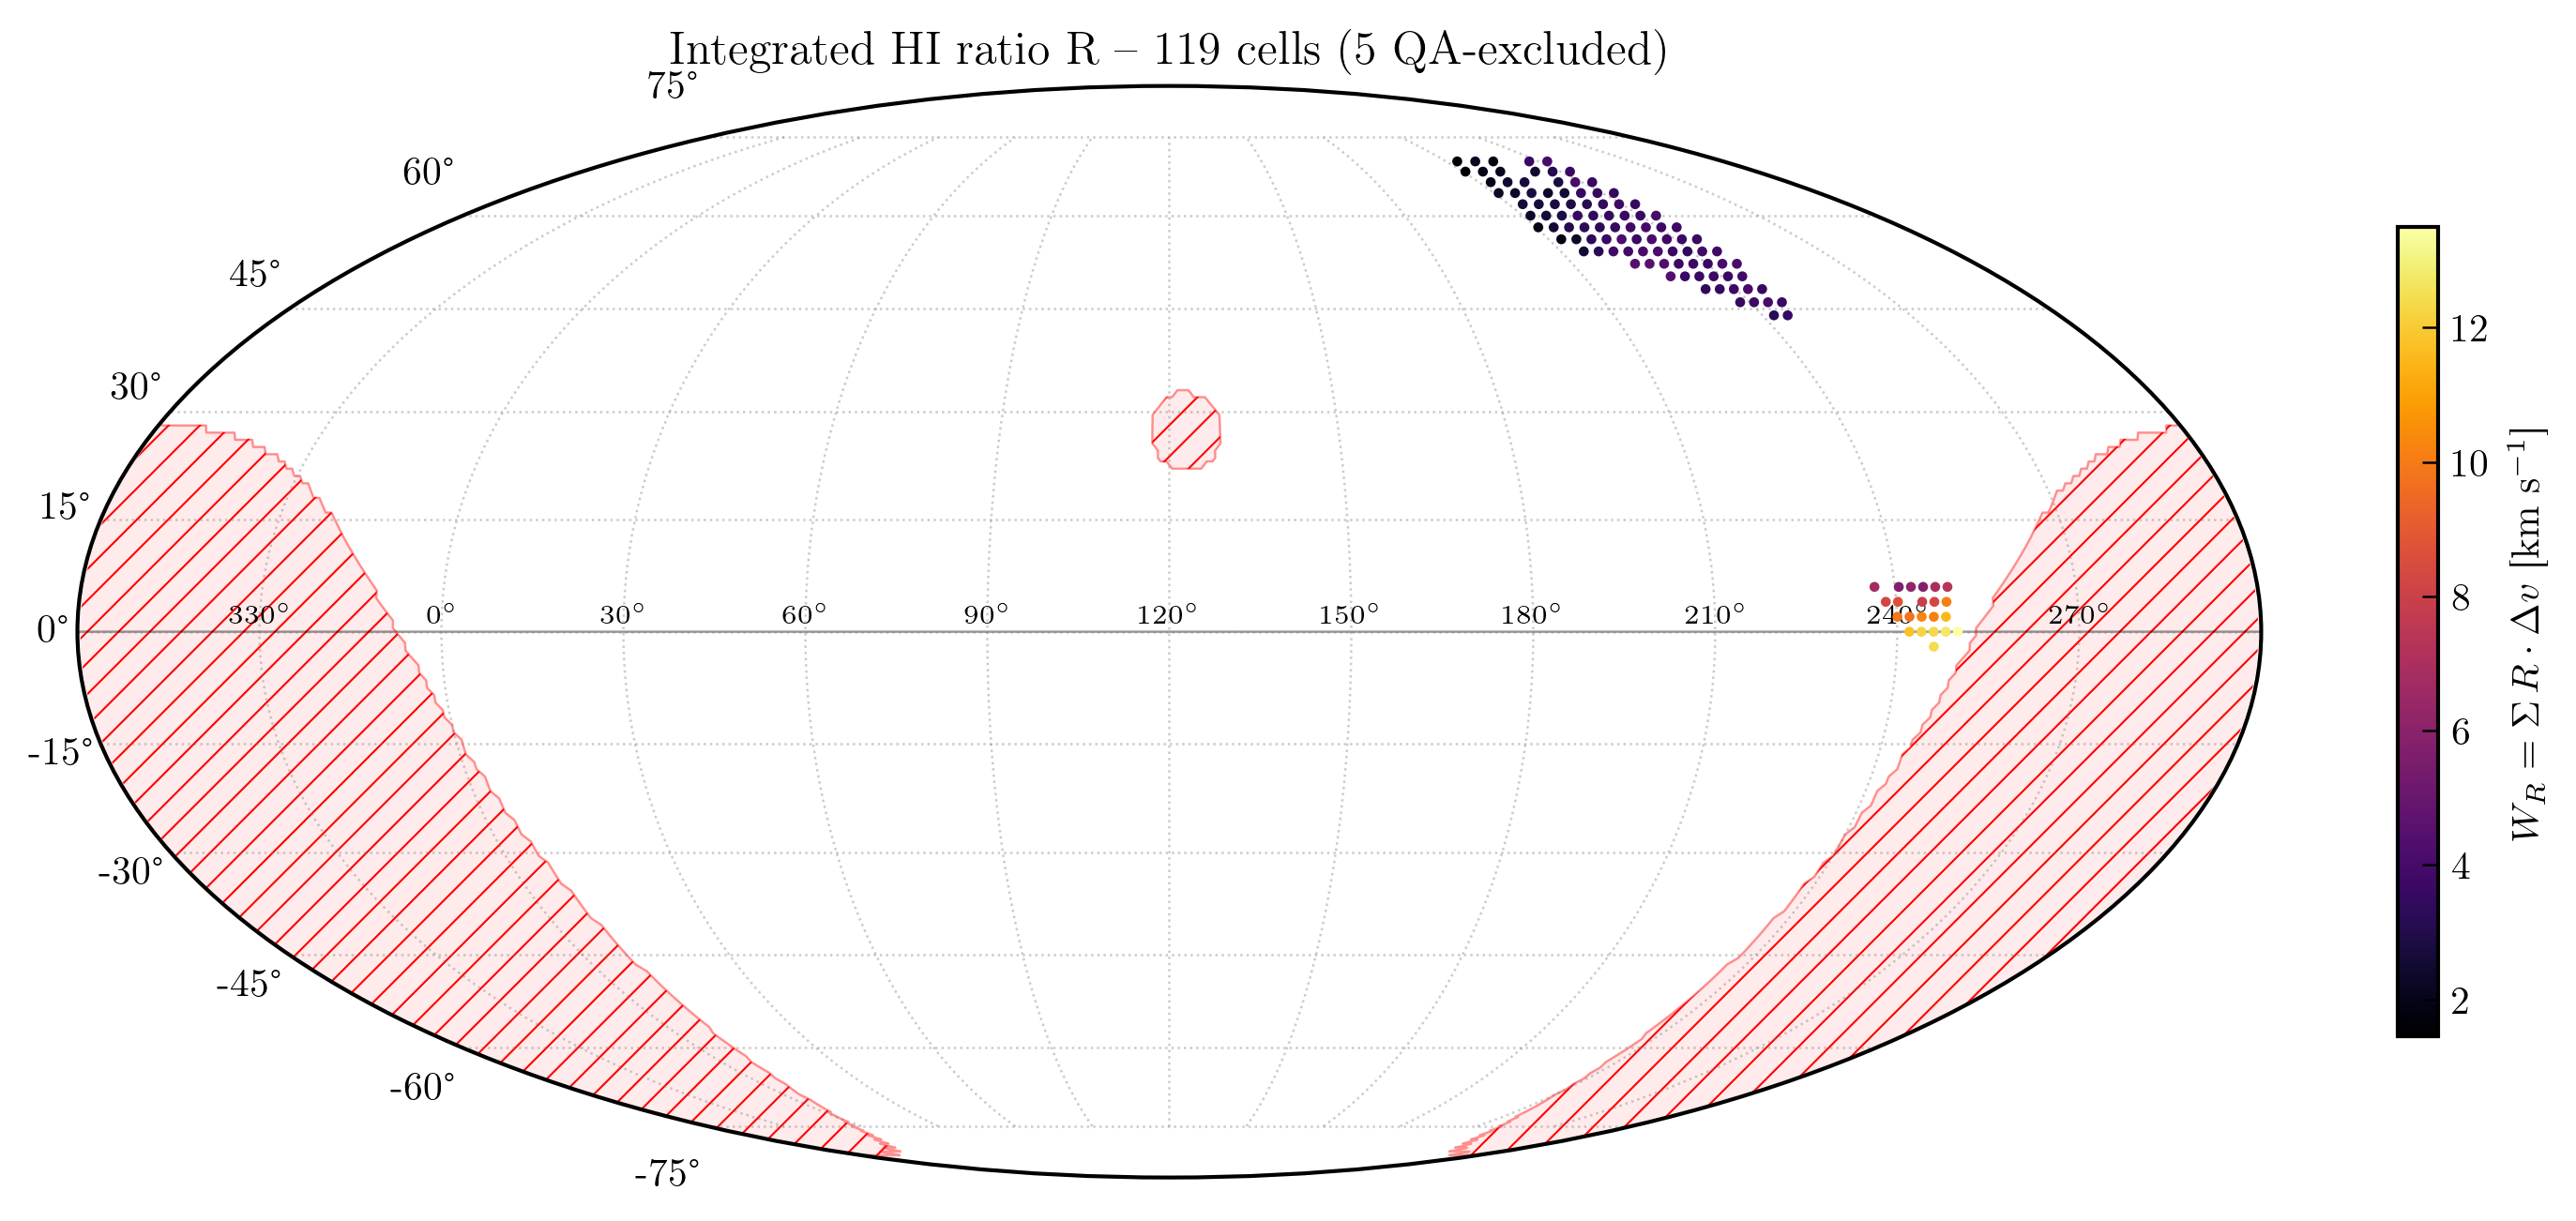

In [10]:
cell_keys_clean = [k for k in cell_combined if k not in qa_flagged_set]
gl_arr = np.array([k[0] for k in cell_keys_clean])
gb_arr = np.array([k[1] for k in cell_keys_clean])
R_stack = np.array([cell_combined[k]['R'] for k in cell_keys_clean])

# Integrated frequency-switched ratio: W_R = sum(R) * dv  [km/s]
W_R = np.nansum(R_stack, axis=1) * dv_kms
valid_R = np.isfinite(W_R)

fig, ax = plot_survey_mollweide(
    gl_arr[valid_R], gb_arr[valid_R], W_R[valid_R],
    center_l=MOLL_CENTER_L,
    cbar_label=r'$W_R = \Sigma\, R \cdot \Delta v$ [km s$^{-1}$]',
    cmap='inferno',
    marker_size=(SS_FINE + SS_MICRO) / 2,
    title=f'Integrated HI ratio R -- {valid_R.sum()} cells ({len(qa_flagged_set)} QA-excluded)',
)
plt.show()


## 7. Beam-weighted Mollweide map of integrated R

Beam-weighted resampling of `W_R(l, b)` onto a fine pixel grid. Each pixel
is a Gaussian-beam-weighted average over pointings whose 3.4 deg HPBW
partially overlaps it (cutoff at 2 * HPBW). Pixels with negligible total
weight are masked so unobserved sky stays blank.

Units are km/s -- no temperature calibration is applied.


/home/ikaros/projects/ay-121/labs/04/plotters.py:557: RuntimeWarning: invalid value encountered in divide
  img = np.where(den > min_weight, num / den, np.nan).reshape(LL.shape)


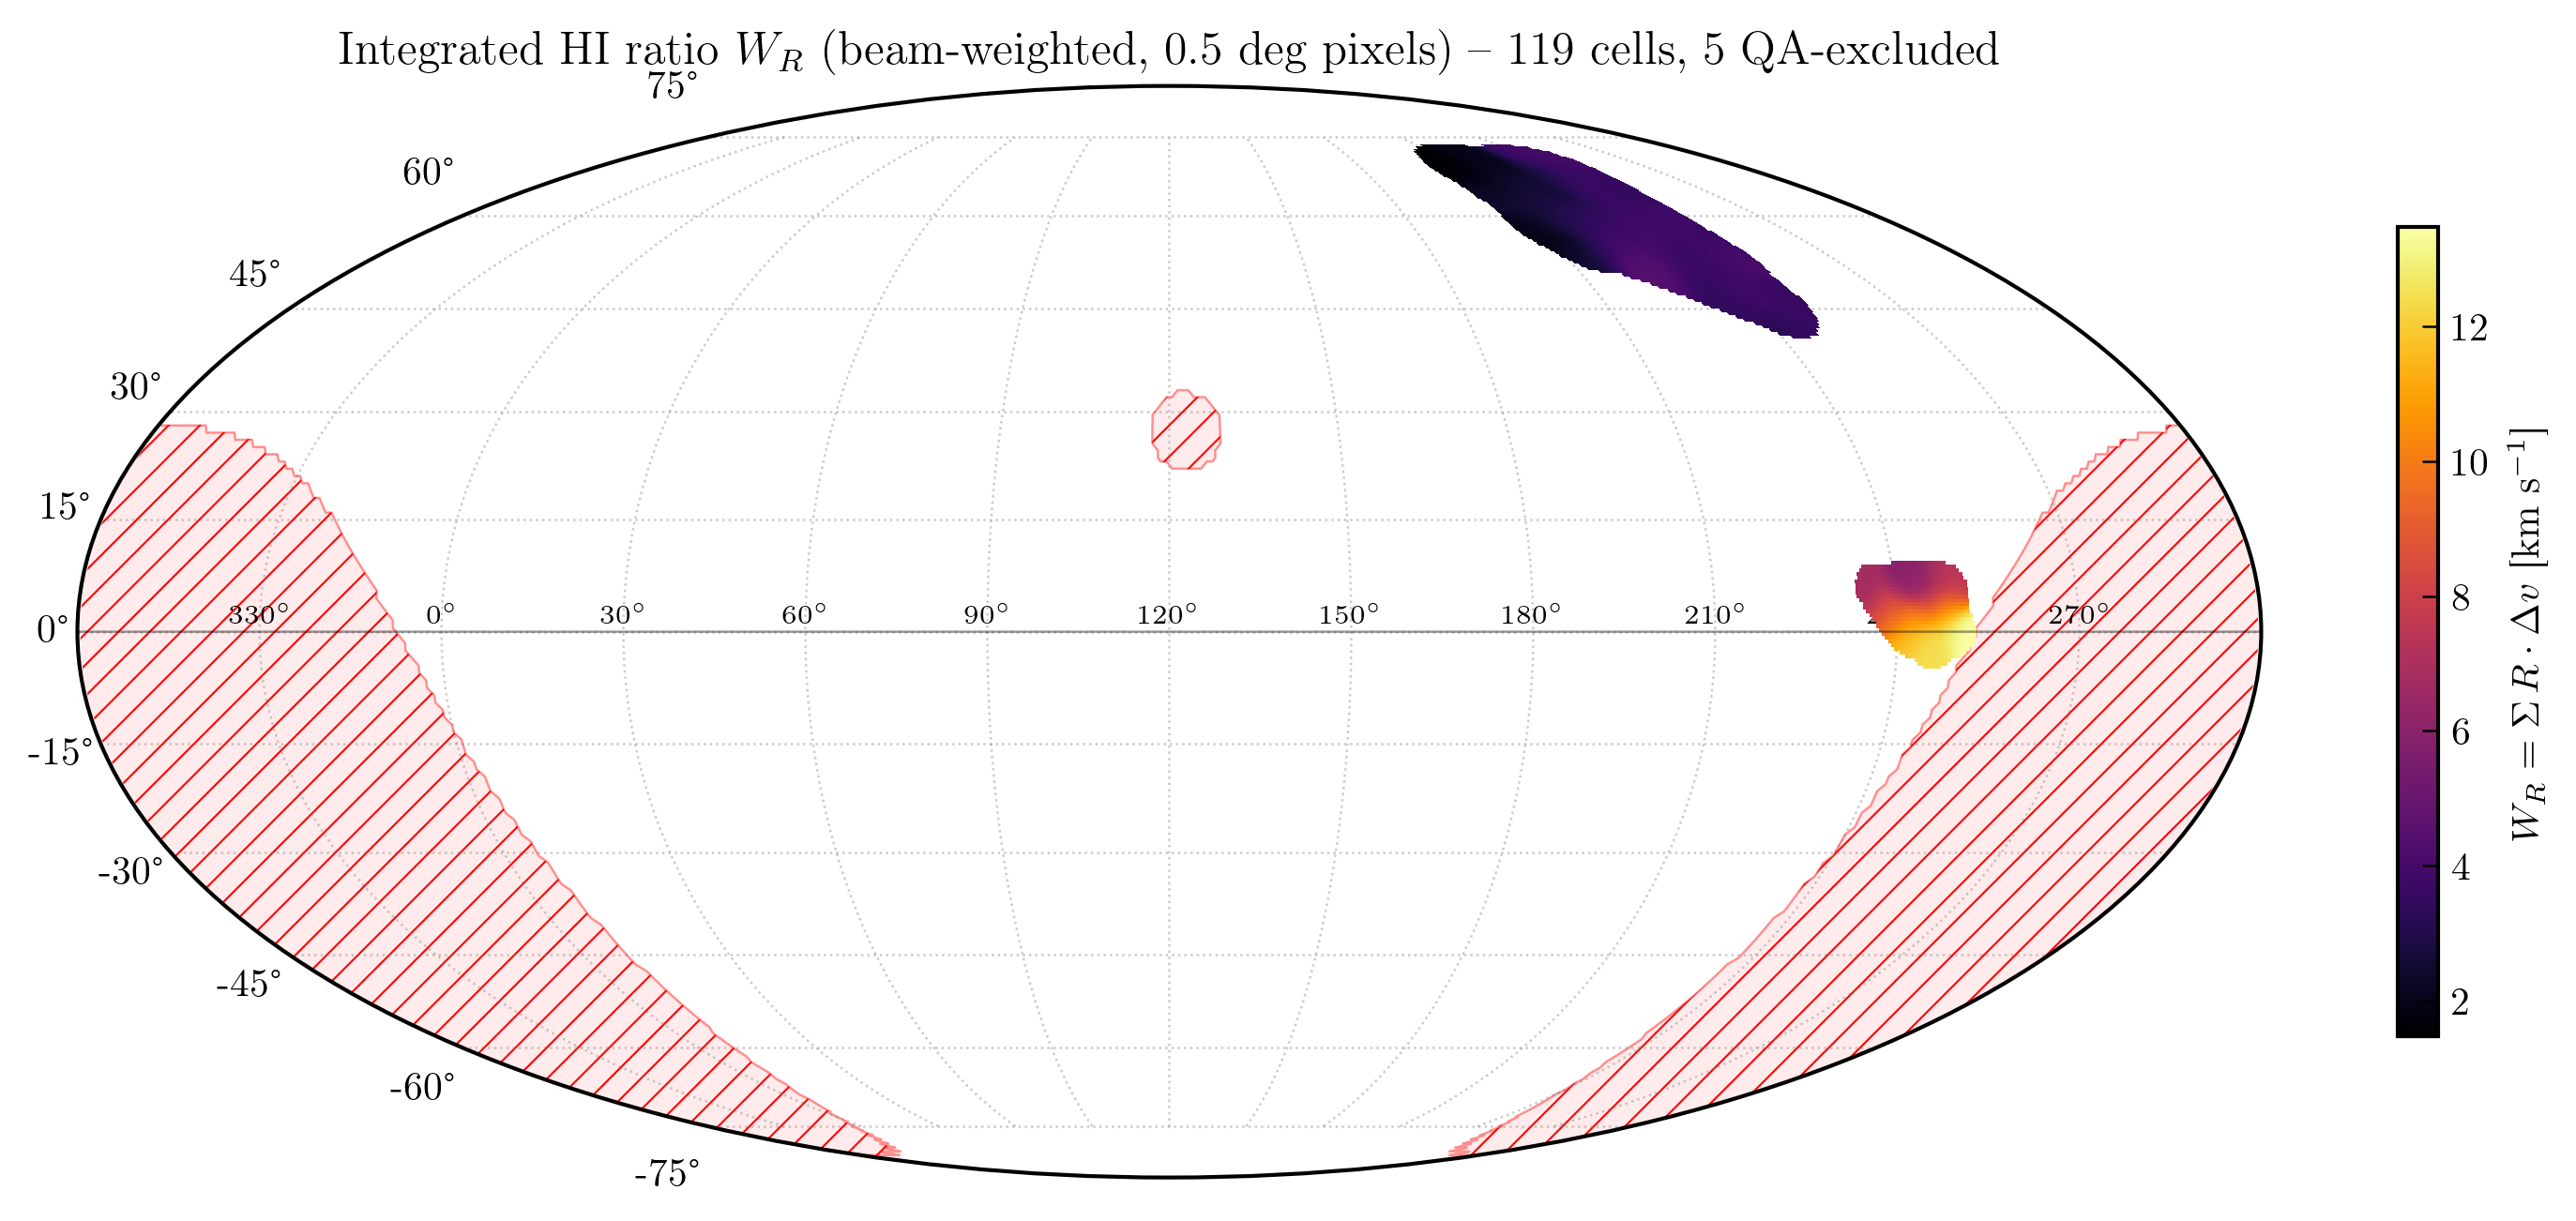

In [11]:
PIXEL_DEG = 0.5      # Mollweide pixel size (deg); finer than HPBW for smooth fill
CUTOFF_HPBW = 2.0    # include pointings within this many HPBW of each pixel center

fig, ax = plot_survey_mollweide_gridded(
    gl_arr[valid_R], gb_arr[valid_R], W_R[valid_R],
    center_l=MOLL_CENTER_L,
    cbar_label=r'$W_R = \Sigma\, R \cdot \Delta v$ [km s$^{-1}$]',
    cmap='inferno',
    hpbw_deg=HPBW_DEG,
    pixel_deg=PIXEL_DEG,
    cutoff_hpbw=CUTOFF_HPBW,
    title=(f'Integrated HI ratio $W_R$ (beam-weighted, {PIXEL_DEG} deg pixels) -- '
           f'{int(valid_R.sum())} cells, {len(qa_flagged_set)} QA-excluded'),
)
plt.show()


In [12]:
# Export state for scan_load_lv.ipynb / scan_load_diagnostics.ipynb.
# No T-calibration: spectra in cell_combined are the dimensionless ratio R(v_LSR).
import pickle

state = {
    'cell_combined': cell_combined,
    'qa_flagged_set': qa_flagged_set,
    'v_lsr_overlap': v_lsr_overlap,
    'dv_kms': dv_kms,
    'overlap_mask': overlap_mask,
    'sessions': sessions,
}
with open(STATE_PATH, 'wb') as f:
    pickle.dump(state, f)
print(f'Wrote {STATE_PATH} ({STATE_PATH.stat().st_size/1e6:.2f} MB) -- '
      f'{len(cell_combined)} cells, {len(qa_flagged_set)} QA-flagged')


Wrote artifacts/scan_load_state.pkl (0.46 MB) -- 124 cells, 5 QA-flagged
